/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26696 (\N{CJK UNIFIED IDEOGRAPH-6848}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from current font.
  fig.canvas.print_figure(b

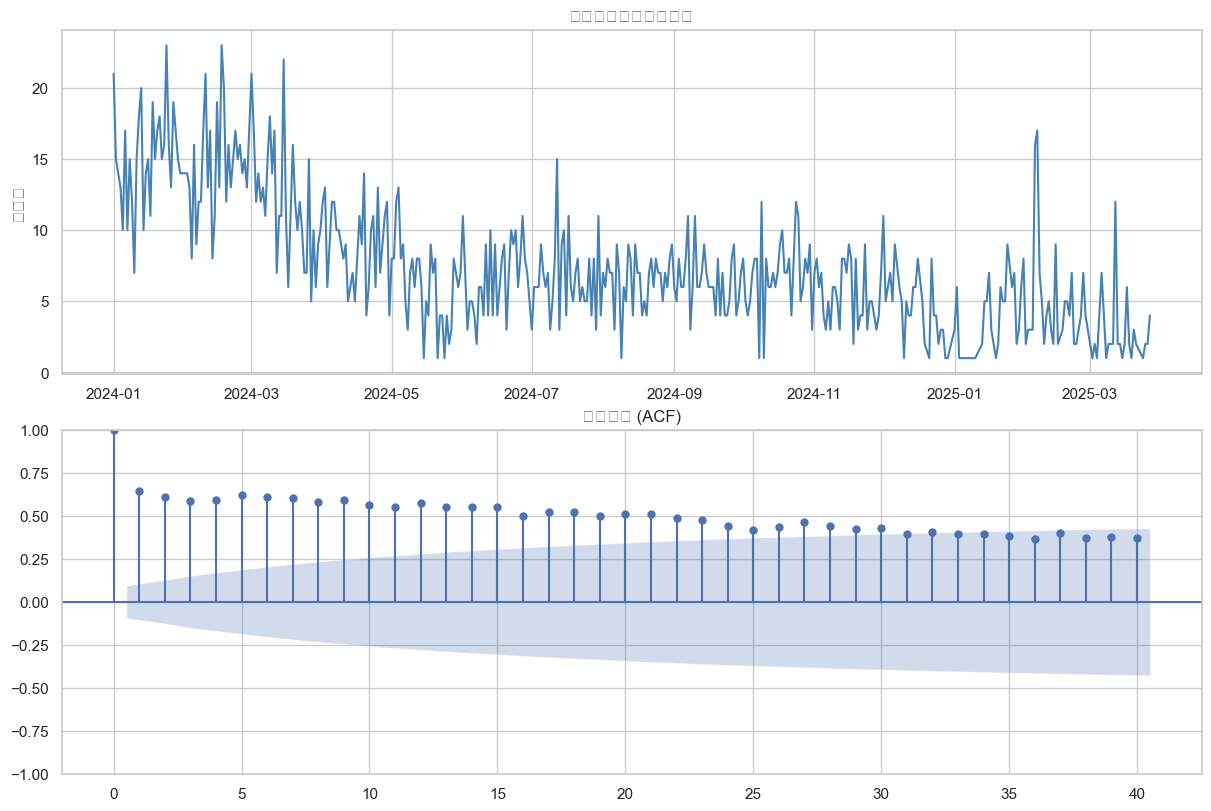

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

# 设置绘图风格
sns.set(style="whitegrid")

# 读取 Excel 文件
file_path = "CrimeDataDelete.xlsx"  # 请替换为你的文件路径
df = pd.read_excel(file_path)

# 转换日期格式
df["DATE OCC"] = pd.to_datetime(df["DATE OCC"])

# 构造每日犯罪次数的时间序列
crime_per_day = df.groupby(df["DATE OCC"].dt.date).size()
crime_per_day.index = pd.to_datetime(crime_per_day.index)

# 绘图
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

# 时间序列图
axes[0].plot(crime_per_day, color='steelblue')
axes[0].set_title("每日犯罪次数时间序列")
axes[0].set_ylabel("案件数")

# 自相关图
plot_acf(crime_per_day, ax=axes[1], lags=40)
axes[1].set_title("自相关图 (ACF)")

plt.show()


In [3]:
from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(crime_per_day)
print("ADF Test:")
print(f"Test Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print("Critical Values:", adf_result[4])
print("=> Reject null hypothesis" if adf_result[1] < 0.05 else "=> Fail to reject null hypothesis")

# KPSS Test
kpss_stat, kpss_pval, _, _ = kpss(crime_per_day, regression='c', nlags="auto")
print("\nKPSS Test:")
print(f"Test Statistic: {kpss_stat}")
print(f"p-value: {kpss_pval}")
print("=> Reject null hypothesis" if kpss_pval < 0.05 else "=> Fail to reject null hypothesis")


ADF Test:
Test Statistic: -1.7451076577213336
p-value: 0.40803418265074637
Critical Values: {'1%': -3.445757604526768, '5%': -2.8683325885102855, '10%': -2.5703882165206853}
=> Fail to reject null hypothesis

KPSS Test:
Test Statistic: 2.6528386580874774
p-value: 0.01
=> Reject null hypothesis


/var/folders/w6/sb9fr_ps5dj9xnt42051pfv40000gn/T/ipykernel_43689/3122292131.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pval, _, _ = kpss(crime_per_day, regression='c', nlags="auto")


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  fig.canvas.print_figure(b

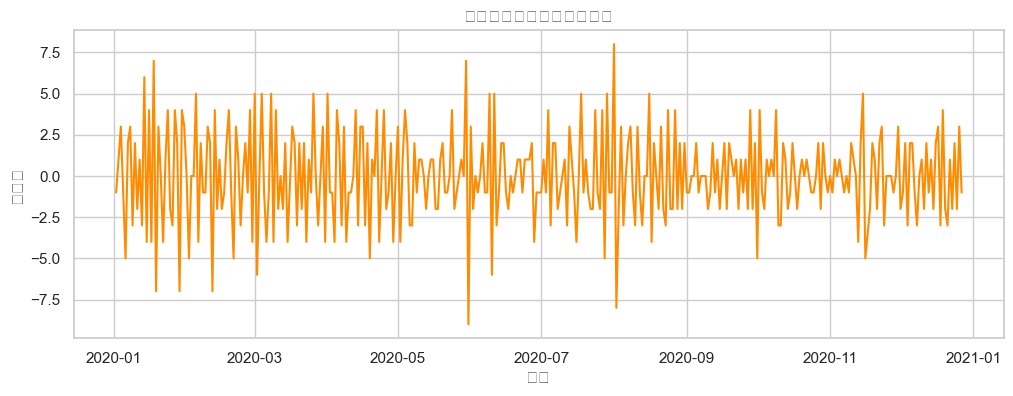

ADF Test (差分后):
Test Statistic: -10.601235606679259
p-value: 6.163469042925282e-19
Critical Values: {'1%': -3.4493918438232525, '5%': -2.8699298018856574, '10%': -2.5712397066390458}
=> Reject null hypothesis

KPSS Test (差分后):
Test Statistic: 0.16460924387863882
p-value: 0.1
=> Fail to reject null hypothesis


/var/folders/w6/sb9fr_ps5dj9xnt42051pfv40000gn/T/ipykernel_36741/3806338633.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat_diff, kpss_pval_diff, _, _ = kpss(diff_series, regression='c', nlags="auto")


In [4]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

# 一阶差分
diff_series = crime_per_day.diff().dropna()

# 绘制差分序列
plt.figure(figsize=(12, 4))
plt.plot(diff_series, color='darkorange')
plt.title("一阶差分后的每日犯罪次数")
plt.ylabel("差分值")
plt.xlabel("日期")
plt.grid(True)
plt.show()

# ADF 检验
adf_result_diff = adfuller(diff_series)
print("ADF Test (差分后):")
print(f"Test Statistic: {adf_result_diff[0]}")
print(f"p-value: {adf_result_diff[1]}")
print("Critical Values:", adf_result_diff[4])
print("=> Reject null hypothesis" if adf_result_diff[1] < 0.05 else "=> Fail to reject null hypothesis")

# KPSS 检验
kpss_stat_diff, kpss_pval_diff, _, _ = kpss(diff_series, regression='c', nlags="auto")
print("\nKPSS Test (差分后):")
print(f"Test Statistic: {kpss_stat_diff}")
print(f"p-value: {kpss_pval_diff}")
print("=> Reject null hypothesis" if kpss_pval_diff < 0.05 else "=> Fail to reject null hypothesis")


In [1]:
pip install pandas matplotlib statsmodels openpyxl


Note: you may need to restart the kernel to use updated packages.


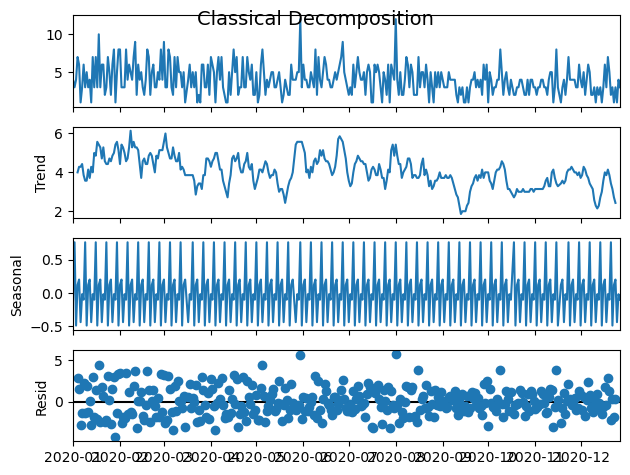

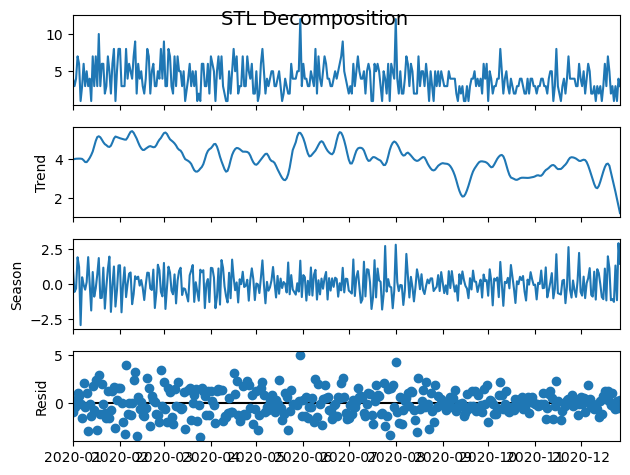

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# 1. 读取 Excel 数据
file_path = "CrimeDataDelete.xlsx"  # 替换为你自己的文件路径
df = pd.read_excel(file_path)

# 2. 构造每日犯罪次数时间序列
df["DATE OCC"] = pd.to_datetime(df["DATE OCC"])
crime_per_day = df.groupby(df["DATE OCC"].dt.date).size()
crime_per_day.index = pd.to_datetime(crime_per_day.index)

# 3. Classical Decomposition（经典分解）
decomp_classical = seasonal_decompose(crime_per_day, model='additive', period=7)

# 4. STL Decomposition（季节-趋势分离）
stl = STL(crime_per_day, period=7)
decomp_stl = stl.fit()

# 5. 绘图 - Classical
fig1 = decomp_classical.plot()
fig1.suptitle("Classical Decomposition", fontsize=14)

# 6. 绘图 - STL
fig2 = decomp_stl.plot()
fig2.suptitle("STL Decomposition", fontsize=14)

plt.show()
